In [1]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

from concurrent.futures import ThreadPoolExecutor
import os

import scipy.linalg as la
import matplotlib.pyplot as plt
from scripts.constants import *
from scripts.hamiltonian_v2 import *
from scripts.self_consistency_v2 import *


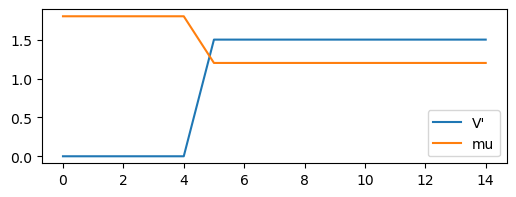

In [2]:
X, Y = 15, 200
lattice = Lattice(X, Y)

widthN = 5
widthP = 10
t = 1
T = 0.02
muN = 1.2 * t
muP = 1.8 * t
mu = np.zeros(lattice.X)
mu[5:] = muN
mu[:5] = muP

U0 = 5.2 * t
U = U0 * np.ones(lattice.X)
U[5:] = 0
U = None
V0 = 1.5 * t 
V = V0 * np.ones(lattice.X)
V = None
V_prime = V0 * np.ones(lattice.X)
V_prime[:5] = 0
plt.figure(figsize=(6,2))
if U is not None:
    plt.plot(U, label="U")
if V is not None:
    plt.plot(V, label="V")
if V_prime is not None:
    plt.plot(V_prime, label="V'")
plt.plot(mu, label='mu')
plt.legend()

In [3]:
H = Hamiltonian(t, mu, lattice, U=U, V_prime=V_prime, V=V, Fuu_init=[0.1, -0.1, 0.1j, -0.1j])


In [4]:
print(is_hermitian(H.build_Hk(PI/4)))
print(is_hermitian(H.matrix))

True
True


In [5]:
i = 0
gap0 = np.array([0.1 + 0.2j])
block = np.zeros((4, 4), dtype=np.complex128)
block[0, 3] = -gap0[i]
block[1, 2] = gap0[i]
block[2, 1] = gap0[i].conj()
block[3, 0] = (-gap0[i]).conj()

print(block)

block = np.zeros((4, 4), dtype=np.complex128)
block[:2, 2:] = -1j * gap0 * s2
block[2:, :2] = (-1j * gap0 * s2).conj().T

print(block)


[[ 0. +0.j   0. +0.j   0. +0.j  -0.1-0.2j]
 [ 0. +0.j   0. +0.j   0.1+0.2j  0. +0.j ]
 [ 0. +0.j   0.1-0.2j  0. +0.j   0. +0.j ]
 [-0.1+0.2j  0. +0.j   0. +0.j   0. +0.j ]]
[[ 0. +0.j   0. +0.j   0. +0.j  -0.1-0.2j]
 [ 0. +0.j   0. +0.j   0.1+0.2j  0. +0.j ]
 [ 0. -0.j   0.1-0.2j  0. +0.j   0. +0.j ]
 [-0.1+0.2j  0. -0.j   0. +0.j   0. +0.j ]]


In [6]:
bdg_self_consistency(H, maxiter=1000, temperature=T, atol=1e-4, rtol=0.1, verbose=True) # CHECK: triplet y- and singlet BCS

Iteration 1:
F0:
Absolute error: 1.9732750117352116e-17
Relative error: 1.9732750117352117e-05
Average_old: 0j
Average_new: (1.5960785437936043e-18+0j)
F_xplus:
Absolute error: 1.4838627480405843e-17
Relative error: 1.4838627480405842e-05
Average_old: 0j
Average_new: (2.0037525765038563e-18+0j)
F_xmin:
Absolute error: 2.320361722402529e-17
Relative error: 2.320361722402529e-05
Average_old: 0j
Average_new: (1.544210216600405e-19+0j)
F_yplus:
Absolute error: 1.969807806163804e-17
Relative error: 1.9698078061638042e-05
Average_old: 0j
Average_new: (1.1812650415685138e-18-6.801206112804787e-19j)
F_ymin:
Absolute error: 1.969807806163804e-17
Relative error: 1.9698078061638042e-05
Average_old: 0j
Average_new: (1.1812650415685138e-18+6.801206112804787e-19j)
Fuu_xplus:
Absolute error: 0.10202691479487007
Relative error: 74834409115.58856
Average_old: (0.06428571428571428+0j)
Average_new: (0.08596690540106168+0j)
Fuu_xmin:
Absolute error: 0.0851365609592927
Relative error: 35711024903.754814
Av

In [7]:
bdg_self_consistency(H, maxiter=100, atol=1e-4, rtol=0.1, verbose=True) # CHECK: triplet y- and singlet BCS


Iteration 1:
F0:
Absolute error: 3.2543279497597806e-17
Relative error: 3.2543211356861344e-05
Average_old: (-1.242417131836076e-18+0j)
Average_new: (-8.660127221462243e-19+0j)
F_xplus:
Absolute error: 3.460385380747099e-17
Relative error: 3.460364935768557e-05
Average_old: (3.1315567266949237e-18+0j)
Average_new: (-8.572062988326097e-19+0j)
F_xmin:
Absolute error: 1.710624138268506e-17
Relative error: 1.7106199210845467e-05
Average_old: (1.52139893021303e-18+0j)
Average_new: (5.284323953366056e-19+0j)
F_yplus:
Absolute error: 3.194109590178408e-17
Relative error: 3.194108853454865e-05
Average_old: (1.0025707261481837e-18+6.77098463966403e-19j)
Average_new: (1.2562023675153855e-18-4.2346176941524795e-19j)
F_ymin:
Absolute error: 3.194109590178408e-17
Relative error: 3.194108853454865e-05
Average_old: (1.0025707261481837e-18-6.77098463966403e-19j)
Average_new: (1.2562023675153855e-18+4.2346176941524795e-19j)
Fuu_xplus:
Absolute error: 0.44640038861910364
Relative error: 3.73857314226041

In [8]:
F0, F_xplus, F_xmin, F_yplus, F_ymin,\
Fuu_xplus, Fuu_xmin, Fuu_yplus, Fuu_ymin,\
Fdd_xplus, Fdd_xmin, Fdd_yplus, Fdd_ymin= H.get_correlations()

In [9]:
Nx = F_yplus.shape[0]  # number of x sites

Fx_p = np.zeros(Nx, dtype=complex)
Fx_m = np.zeros(Nx, dtype=complex)
Fx_p[:-1] = Fdd_xplus      # site i gets bond (i,i+1)
Fx_m[1:]  = Fdd_xmin       # site i gets bond (i,i-1).T

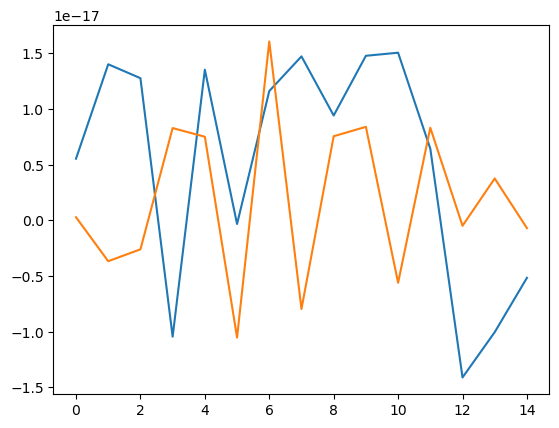

In [10]:
plt.plot(np.real(Fx_p - Fx_m)/2)
plt.plot(np.imag(Fdd_yplus - Fdd_ymin)/2) # TEST: UPDATE ONLY THE SC PART 
# plt.plot(F0)
# plt.plot((Fx_p + Fx_m - F_yplus - F_ymin)/4)